In [7]:
!pip -q install xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss
)

from xgboost import XGBClassifier

from scipy.stats import poisson

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [8]:
import pandas as pd
import numpy as np

matches_clean = pd.read_csv("sample_data/matches_men_clean.csv")
classification_df = pd.read_csv("sample_data/mens_classification_dataset.csv")
elo_df = pd.read_csv("sample_data/mens_final_elo.csv")
modeling_df = pd.read_csv("sample_data/mens_modeling_dataset.csv")
poisson_df = pd.read_csv("sample_data/mens_poisson_dataset.csv")

print("Datasets loaded successfully.\n")

print("Clean matches:", matches_clean.shape)
print("Classification dataset:", classification_df.shape)
print("Elo ratings:", elo_df.shape)
print("Modeling dataset:", modeling_df.shape)
print("Poisson dataset:", poisson_df.shape)

Datasets loaded successfully.

Clean matches: (358, 17)
Classification dataset: (358, 29)
Elo ratings: (64, 3)
Modeling dataset: (358, 33)
Poisson dataset: (358, 29)


In [9]:
datasets = {
    "matches_clean": matches_clean,
    "classification_df": classification_df,
    "elo_df": elo_df,
    "modeling_df": modeling_df,
    "poisson_df": poisson_df
}

for name, df in datasets.items():

    print("=" * 70)
    print(name)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print()


matches_clean
Shape: (358, 17)

Columns:
['date', 'tournament', 'year', 'round', 'team_a', 'team_b', 'score_a', 'score_b', 'ft_goals1', 'ft_goals2', 'penalty1', 'penalty2', 'result', 'group', 'ground', 'total_goals', 'goal_difference']

classification_df
Shape: (358, 29)

Columns:
['date', 'tournament', 'year', 'round', 'team_a', 'team_b', 'elo_a', 'elo_b', 'elo_diff', 'form_points_a', 'form_points_b', 'form_diff', 'avg_goals_for_a', 'avg_goals_for_b', 'goals_for_diff', 'avg_goals_against_a', 'avg_goals_against_b', 'goals_against_diff', 'avg_goal_diff_a', 'avg_goal_diff_b', 'recent_goal_diff', 'win_rate_a', 'win_rate_b', 'win_rate_diff', 'recent_games_a', 'recent_games_b', 'is_knockout', 'result', 'target']

elo_df
Shape: (64, 3)

Columns:
['rank', 'team', 'elo_rating']

modeling_df
Shape: (358, 33)

Columns:
['date', 'tournament', 'year', 'round', 'team_a', 'team_b', 'elo_a', 'elo_b', 'elo_diff', 'recent_games_a', 'recent_games_b', 'form_points_a', 'form_points_b', 'form_diff', 'avg_g

In [10]:
matches = classification_df.copy()

# Dataset for Poisson model
poisson_matches = poisson_df.copy()

# Elo ratings
elo_ratings = elo_df.copy()

print("Classification data:", matches.shape)
print("Poisson data:", poisson_matches.shape)
print("Elo data:", elo_ratings.shape)

print("\nClassification columns:")
print(matches.columns.tolist())

Classification data: (358, 29)
Poisson data: (358, 29)
Elo data: (64, 3)

Classification columns:
['date', 'tournament', 'year', 'round', 'team_a', 'team_b', 'elo_a', 'elo_b', 'elo_diff', 'form_points_a', 'form_points_b', 'form_diff', 'avg_goals_for_a', 'avg_goals_for_b', 'goals_for_diff', 'avg_goals_against_a', 'avg_goals_against_b', 'goals_against_diff', 'avg_goal_diff_a', 'avg_goal_diff_b', 'recent_goal_diff', 'win_rate_a', 'win_rate_b', 'win_rate_diff', 'recent_games_a', 'recent_games_b', 'is_knockout', 'result', 'target']


In [11]:
display(matches.head())

print("\nData types:")
print(matches.dtypes)

print("\nMissing values:")
print(matches.isna().sum())

,date,tournament,year,round,team_a,team_b,elo_a,elo_b,elo_diff,form_points_a,form_points_b,form_diff,avg_goals_for_a,avg_goals_for_b,goals_for_diff,avg_goals_against_a,avg_goals_against_b,goals_against_diff,avg_goal_diff_a,avg_goal_diff_b,recent_goal_diff,win_rate_a,win_rate_b,win_rate_diff,recent_games_a,recent_games_b,is_knockout,result,target
0,2010-06-11,World Cup,2010,Matchday 1,South Africa,Mexico,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Draw,1
1,2010-06-11,World Cup,2010,Matchday 1,Uruguay,France,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Draw,1
2,2010-06-12,World Cup,2010,Matchday 2,South Korea,Greece,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Team A Win,2
3,2010-06-12,World Cup,2010,Matchday 2,Argentina,Nigeria,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Team A Win,2
4,2010-06-12,World Cup,2010,Matchday 2,England,USA,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Draw,1



Data types:
date                    object
tournament              object
year                     int64
round                   object
team_a                  object
team_b                  object
elo_a                  float64
elo_b                  float64
elo_diff               float64
form_points_a          float64
form_points_b          float64
form_diff              float64
avg_goals_for_a        float64
avg_goals_for_b        float64
goals_for_diff         float64
avg_goals_against_a    float64
avg_goals_against_b    float64
goals_against_diff     float64
avg_goal_diff_a        float64
avg_goal_diff_b        float64
recent_goal_diff       float64
win_rate_a             float64
win_rate_b             float64
win_rate_diff          float64
recent_games_a           int64
recent_games_b           int64
is_knockout              int64
result                  object
target                   int64
dtype: object

Missing values:
date                   0
tournament             0
year   

In [12]:
# ============================================================
# CELL 7 — INSPECT POSSIBLE TARGET / SCORE COLUMNS
# ============================================================

print("Available columns:")
print(matches.columns.tolist())

print("\nDataset shape:")
print(matches.shape)

display(matches.head())

Available columns:
['date', 'tournament', 'year', 'round', 'team_a', 'team_b', 'elo_a', 'elo_b', 'elo_diff', 'form_points_a', 'form_points_b', 'form_diff', 'avg_goals_for_a', 'avg_goals_for_b', 'goals_for_diff', 'avg_goals_against_a', 'avg_goals_against_b', 'goals_against_diff', 'avg_goal_diff_a', 'avg_goal_diff_b', 'recent_goal_diff', 'win_rate_a', 'win_rate_b', 'win_rate_diff', 'recent_games_a', 'recent_games_b', 'is_knockout', 'result', 'target']

Dataset shape:
(358, 29)


,date,tournament,year,round,team_a,team_b,elo_a,elo_b,elo_diff,form_points_a,form_points_b,form_diff,avg_goals_for_a,avg_goals_for_b,goals_for_diff,avg_goals_against_a,avg_goals_against_b,goals_against_diff,avg_goal_diff_a,avg_goal_diff_b,recent_goal_diff,win_rate_a,win_rate_b,win_rate_diff,recent_games_a,recent_games_b,is_knockout,result,target
0,2010-06-11,World Cup,2010,Matchday 1,South Africa,Mexico,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Draw,1
1,2010-06-11,World Cup,2010,Matchday 1,Uruguay,France,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Draw,1
2,2010-06-12,World Cup,2010,Matchday 2,South Korea,Greece,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Team A Win,2
3,2010-06-12,World Cup,2010,Matchday 2,Argentina,Nigeria,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Team A Win,2
4,2010-06-12,World Cup,2010,Matchday 2,England,USA,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Draw,1


In [13]:
# ============================================================
# CELL 8 — FIND SCORE COLUMNS
# ============================================================

def find_first_column(df, choices):
    for col in choices:
        if col in df.columns:
            return col
    return None


home_goal_col = find_first_column(
    matches,
    [
        "home_goals",
        "team1_goals",
        "goals1",
        "score1",
        "home_score",
        "home_goals_regulation"
    ]
)

away_goal_col = find_first_column(
    matches,
    [
        "away_goals",
        "team2_goals",
        "goals2",
        "score2",
        "away_score",
        "away_goals_regulation"
    ]
)

print("Home goal column:", home_goal_col)
print("Away goal column:", away_goal_col)

Home goal column: None
Away goal column: None


In [14]:
!pip -q install xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from scipy.stats import poisson

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries loaded.")

Libraries loaded.


In [15]:
# ============================================================
# VERIFY TARGET
# ============================================================

if "target" not in matches.columns:
    raise ValueError(
        "The classification dataset does not contain a target column."
    )

matches["target"] = pd.to_numeric(
    matches["target"],
    errors="coerce"
)

matches = matches.dropna(
    subset=["target"]
).copy()

matches["target"] = matches["target"].astype(int)

print("Target counts:")
print(matches["target"].value_counts().sort_index())

print("\nTarget meaning:")
print("0 = Team B Win")
print("1 = Draw")
print("2 = Team A Win")

print("\nClasses found:")
print(sorted(matches["target"].unique()))

if matches["target"].nunique() < 2:
    raise ValueError(
        "Target has fewer than 2 classes. "
        "Check the previous data-preparation notebook."
    )

Target counts:
target
0    130
1     86
2    142
Name: count, dtype: int64

Target meaning:
0 = Team B Win
1 = Draw
2 = Team A Win

Classes found:
[np.int64(0), np.int64(1), np.int64(2)]


In [16]:
# ============================================================
# SELECT MODEL FEATURES
# ============================================================

feature_cols = [
    "elo_a",
    "elo_b",
    "elo_diff",

    "form_points_a",
    "form_points_b",
    "form_diff",

    "avg_goals_for_a",
    "avg_goals_for_b",
    "goals_for_diff",

    "avg_goals_against_a",
    "avg_goals_against_b",
    "goals_against_diff",

    "avg_goal_diff_a",
    "avg_goal_diff_b",
    "recent_goal_diff",

    "win_rate_a",
    "win_rate_b",
    "win_rate_diff",

    "recent_games_a",
    "recent_games_b",

    "is_knockout"
]

missing = [
    col for col in feature_cols
    if col not in matches.columns
]

if missing:
    print("Missing columns:")
    print(missing)
    raise ValueError("Some model features are missing.")

X = matches[feature_cols].copy()
y = matches["target"].copy()

# Remove infinities
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill missing values with median
X = X.fillna(
    X.median(numeric_only=True)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

display(X.head())

X shape: (358, 21)
y shape: (358,)

Target distribution:
target
0    130
1     86
2    142
Name: count, dtype: int64


,elo_a,elo_b,elo_diff,form_points_a,form_points_b,form_diff,avg_goals_for_a,avg_goals_for_b,goals_for_diff,avg_goals_against_a,avg_goals_against_b,goals_against_diff,avg_goal_diff_a,avg_goal_diff_b,recent_goal_diff,win_rate_a,win_rate_b,win_rate_diff,recent_games_a,recent_games_b,is_knockout
0,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0
1,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0
2,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0
3,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0
4,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0


In [17]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

all_indices = np.arange(len(matches))

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Training matches:", len(X_train))
print("Testing matches:", len(X_test))

print("\nTRAIN TARGET COUNTS")
print(y_train.value_counts().sort_index())

print("\nTEST TARGET COUNTS")
print(y_test.value_counts().sort_index())

if y_train.nunique() < 2:
    raise ValueError(
        "Training data only contains one class."
    )

Training matches: 268
Testing matches: 90

TRAIN TARGET COUNTS
target
0     97
1     65
2    106
Name: count, dtype: int64

TEST TARGET COUNTS
target
0    33
1    21
2    36
Name: count, dtype: int64


In [18]:
# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================

model_results = []

trained_models = {}
predictions = {}
probabilities = {}

class_order = np.array([0, 1, 2])

class_names = [
    "Team B Win",
    "Draw",
    "Team A Win"
]


def evaluate_classifier(
    name,
    model,
    X_train,
    X_test,
    y_train,
    y_test
):

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(X_test)

    raw_prob = model.predict_proba(X_test)

    # Force probability columns into 0,1,2 order
    y_prob = np.zeros(
        (len(X_test), 3)
    )

    for j, cls in enumerate(model.classes_):
        y_prob[:, int(cls)] = raw_prob[:, j]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    loss = log_loss(
        y_test,
        y_prob,
        labels=class_order
    )

    model_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Macro F1": macro_f1,
        "Log Loss": loss
    })

    trained_models[name] = model
    predictions[name] = y_pred
    probabilities[name] = y_prob

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        f"Accuracy: {accuracy:.3f}"
    )

    print(
        f"Macro F1: {macro_f1:.3f}"
    )

    print(
        f"Log Loss: {loss:.3f}"
    )

    print()

    print(
        classification_report(
            y_test,
            y_pred,
            labels=class_order,
            target_names=class_names,
            zero_division=0
        )
    )

    return model

In [19]:
logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        LogisticRegression(
            max_iter=3000,
            random_state=RANDOM_STATE
        )
    )
])

logistic_model = evaluate_classifier(
    "Logistic Regression",
    logistic_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Logistic Regression
Accuracy: 0.467
Macro F1: 0.415
Log Loss: 1.091

              precision    recall  f1-score   support

  Team B Win       0.50      0.64      0.56        33
        Draw       0.23      0.14      0.18        21
  Team A Win       0.51      0.50      0.51        36

    accuracy                           0.47        90
   macro avg       0.42      0.43      0.41        90
weighted avg       0.44      0.47      0.45        90



In [20]:
random_forest_model = RandomForestClassifier(
    n_estimators=500,

    max_depth=8,

    min_samples_leaf=3,

    class_weight="balanced",

    random_state=RANDOM_STATE,

    n_jobs=-1
)

random_forest_model = evaluate_classifier(
    "Random Forest",
    random_forest_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Random Forest
Accuracy: 0.511
Macro F1: 0.452
Log Loss: 1.038

              precision    recall  f1-score   support

  Team B Win       0.52      0.70      0.60        33
        Draw       0.21      0.14      0.17        21
  Team A Win       0.62      0.56      0.59        36

    accuracy                           0.51        90
   macro avg       0.45      0.47      0.45        90
weighted avg       0.49      0.51      0.49        90



In [21]:
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=150,

    learning_rate=0.05,

    max_depth=2,

    random_state=RANDOM_STATE
)

gradient_boosting_model = evaluate_classifier(
    "Gradient Boosting",
    gradient_boosting_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Gradient Boosting
Accuracy: 0.478
Macro F1: 0.417
Log Loss: 1.056

              precision    recall  f1-score   support

  Team B Win       0.52      0.42      0.47        33
        Draw       0.20      0.14      0.17        21
  Team A Win       0.54      0.72      0.62        36

    accuracy                           0.48        90
   macro avg       0.42      0.43      0.42        90
weighted avg       0.45      0.48      0.46        90



In [22]:
xgboost_model = XGBClassifier(
    objective="multi:softprob",

    num_class=3,

    n_estimators=250,

    learning_rate=0.04,

    max_depth=3,

    min_child_weight=2,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_lambda=1.0,

    eval_metric="mlogloss",

    random_state=RANDOM_STATE,

    n_jobs=-1
)

xgboost_model = evaluate_classifier(
    "XGBoost",
    xgboost_model,
    X_train,
    X_test,
    y_train,
    y_test
)

XGBoost
Accuracy: 0.467
Macro F1: 0.391
Log Loss: 1.125

              precision    recall  f1-score   support

  Team B Win       0.52      0.52      0.52        33
        Draw       0.08      0.05      0.06        21
  Team A Win       0.55      0.67      0.60        36

    accuracy                           0.47        90
   macro avg       0.38      0.41      0.39        90
weighted avg       0.43      0.47      0.44        90



In [23]:
# ============================================================
# POISSON MODEL
# ============================================================

required_cols = [
    "poisson_goals_a",
    "poisson_goals_b"
]

missing = [
    col for col in required_cols
    if col not in poisson_matches.columns
]

if missing:
    raise ValueError(
        f"Poisson columns missing: {missing}"
    )


poisson_test = poisson_matches.iloc[
    test_idx
].copy()


def poisson_result_probabilities(
    lambda_a,
    lambda_b,
    max_goals=10
):

    lambda_a = max(
        float(lambda_a),
        1e-6
    )

    lambda_b = max(
        float(lambda_b),
        1e-6
    )

    goals = np.arange(
        max_goals + 1
    )

    prob_a = poisson.pmf(
        goals,
        lambda_a
    )

    prob_b = poisson.pmf(
        goals,
        lambda_b
    )

    score_matrix = np.outer(
        prob_a,
        prob_b
    )

    # Team A win
    prob_a_win = np.tril(
        score_matrix,
        k=-1
    ).sum()

    # Draw
    prob_draw = np.trace(
        score_matrix
    )

    # Team B win
    prob_b_win = np.triu(
        score_matrix,
        k=1
    ).sum()

    probs = np.array([
        prob_b_win,
        prob_draw,
        prob_a_win
    ])

    # Normalize
    probs = probs / probs.sum()

    return probs

In [24]:
poisson_probs = np.vstack([
    poisson_result_probabilities(
        a,
        b
    )

    for a, b in zip(
        poisson_test["poisson_goals_a"],
        poisson_test["poisson_goals_b"]
    )
])

poisson_pred = poisson_probs.argmax(
    axis=1
)

poisson_accuracy = accuracy_score(
    y_test,
    poisson_pred
)

poisson_f1 = f1_score(
    y_test,
    poisson_pred,
    average="macro"
)

poisson_loss = log_loss(
    y_test,
    poisson_probs,
    labels=class_order
)


model_results.append({
    "Model": "Poisson",
    "Accuracy": poisson_accuracy,
    "Macro F1": poisson_f1,
    "Log Loss": poisson_loss
})

predictions["Poisson"] = poisson_pred

probabilities["Poisson"] = poisson_probs


print("=" * 60)
print("POISSON MODEL")
print("=" * 60)

print(
    f"Accuracy: {poisson_accuracy:.3f}"
)

print(
    f"Macro F1: {poisson_f1:.3f}"
)

print(
    f"Log Loss: {poisson_loss:.3f}"
)

print()

print(
    classification_report(
        y_test,
        poisson_pred,
        labels=class_order,
        target_names=class_names,
        zero_division=0
    )
)

POISSON MODEL
Accuracy: 0.822
Macro F1: 0.730
Log Loss: 0.477

              precision    recall  f1-score   support

  Team B Win       0.67      1.00      0.80        33
        Draw       1.00      0.24      0.38        21
  Team A Win       1.00      1.00      1.00        36

    accuracy                           0.82        90
   macro avg       0.89      0.75      0.73        90
weighted avg       0.88      0.82      0.78        90



In [25]:
# ============================================================
# MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    model_results
)

results_df = results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(
    results_df.style.format({
        "Accuracy": "{:.3f}",
        "Macro F1": "{:.3f}",
        "Log Loss": "{:.3f}"
    })
)

best_model = results_df.iloc[0]["Model"]

print(
    "\nBest model based on Macro F1:",
    best_model
)

FINAL MODEL COMPARISON


,Model,Accuracy,Macro F1,Log Loss
0,Poisson,0.822,0.730,0.477
1,Random Forest,0.511,0.452,1.038
2,Gradient Boosting,0.478,0.417,1.056
3,Logistic Regression,0.467,0.415,1.091
4,XGBoost,0.467,0.391,1.125



Best model based on Macro F1: Poisson


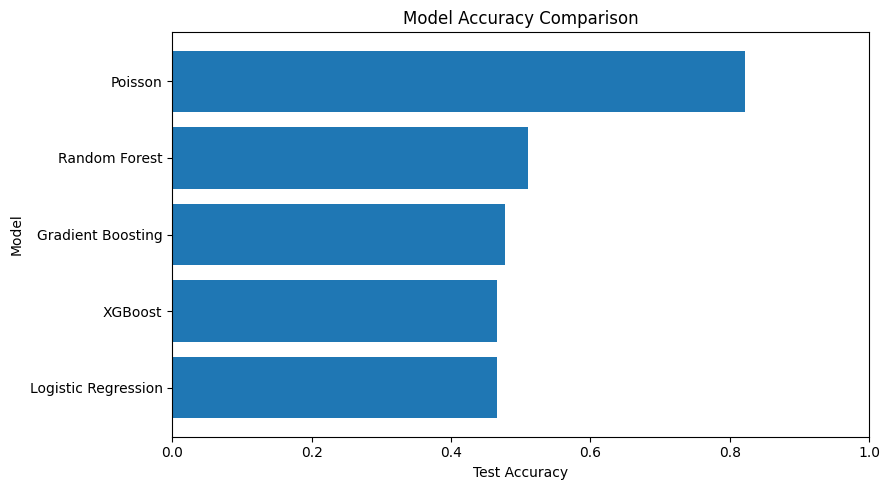

In [26]:
plot_df = results_df.sort_values(
    "Accuracy"
)

plt.figure(
    figsize=(9, 5)
)

plt.barh(
    plot_df["Model"],
    plot_df["Accuracy"]
)

plt.xlabel(
    "Test Accuracy"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Model Accuracy Comparison"
)

plt.xlim(
    0,
    1
)

plt.tight_layout()

plt.show()

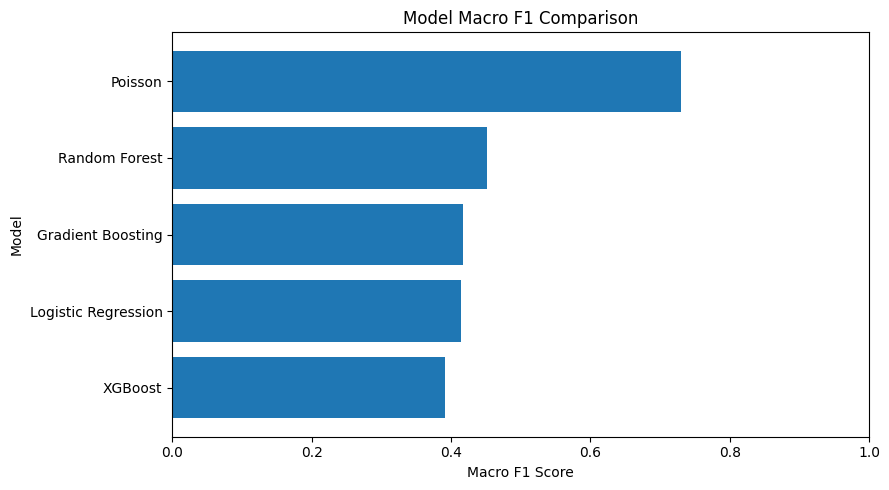

In [27]:
plot_df = results_df.sort_values(
    "Macro F1"
)

plt.figure(
    figsize=(9, 5)
)

plt.barh(
    plot_df["Model"],
    plot_df["Macro F1"]
)

plt.xlabel(
    "Macro F1 Score"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Model Macro F1 Comparison"
)

plt.xlim(
    0,
    1
)

plt.tight_layout()

plt.show()

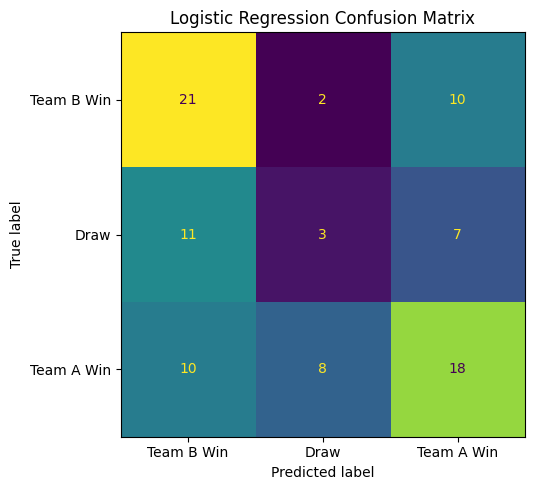

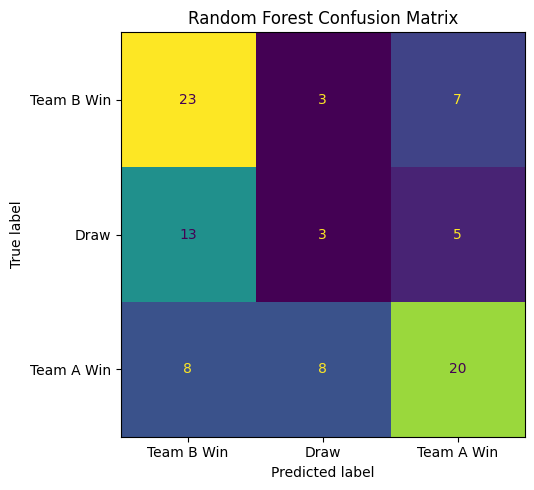

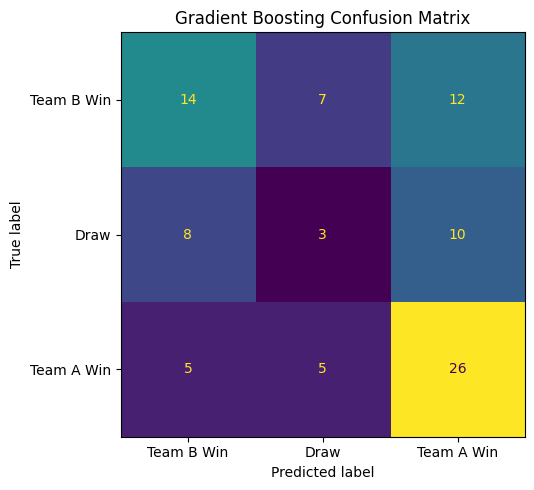

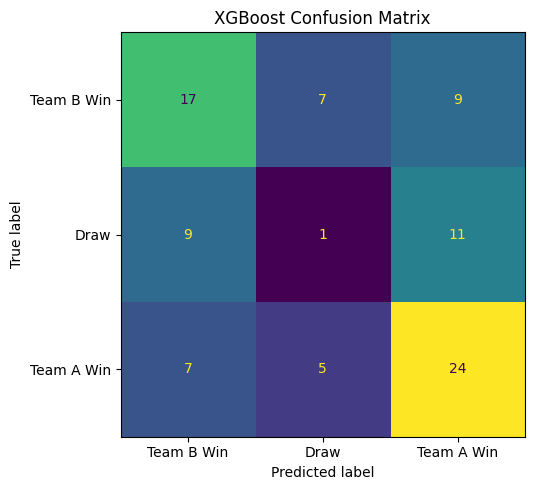

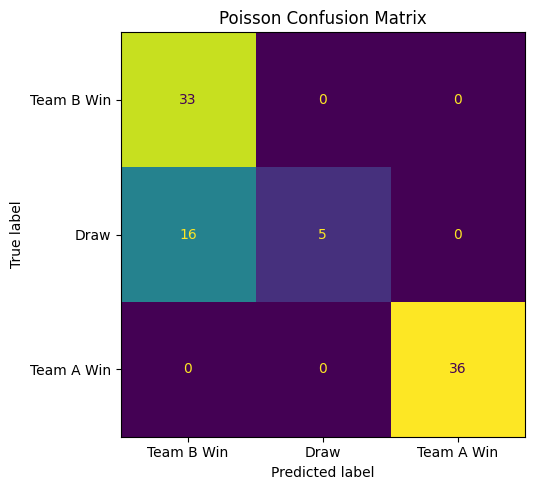

In [28]:
for model_name, y_pred in predictions.items():

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,

        labels=[
            0,
            1,
            2
        ],

        display_labels=[
            "Team B Win",
            "Draw",
            "Team A Win"
        ],

        ax=ax,

        colorbar=False
    )

    ax.set_title(
        f"{model_name} Confusion Matrix"
    )

    plt.tight_layout()

    plt.show()

In [29]:
# ============================================================
# 5-FOLD CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_models = {
    "Logistic Regression":
        logistic_model,

    "Random Forest":
        random_forest_model,

    "Gradient Boosting":
        gradient_boosting_model,

    "XGBoost":
        xgboost_model
}


cv_results = []


for name, model in cv_models.items():

    scores = cross_val_score(
        model,
        X,
        y,

        cv=cv,

        scoring="f1_macro",

        n_jobs=1
    )

    cv_results.append({
        "Model":
            name,

        "Mean CV Macro F1":
            scores.mean(),

        "CV Standard Deviation":
            scores.std()
    })


cv_results_df = pd.DataFrame(
    cv_results
)

cv_results_df = cv_results_df.sort_values(
    "Mean CV Macro F1",
    ascending=False
).reset_index(drop=True)


display(
    cv_results_df.style.format({
        "Mean CV Macro F1":
            "{:.3f}",

        "CV Standard Deviation":
            "{:.3f}"
    })
)

,Model,Mean CV Macro F1,CV Standard Deviation
0,Random Forest,0.384,0.030
1,XGBoost,0.345,0.032
2,Gradient Boosting,0.344,0.035
3,Logistic Regression,0.343,0.022


,Feature,Importance
1,elo_b,0.081557
2,elo_diff,0.079935
0,elo_a,0.078443
8,goals_for_diff,0.064598
6,avg_goals_for_a,0.056105
5,form_diff,0.054410
7,avg_goals_for_b,0.053120
12,avg_goal_diff_a,0.053088
17,win_rate_diff,0.048189
14,recent_goal_diff,0.047508


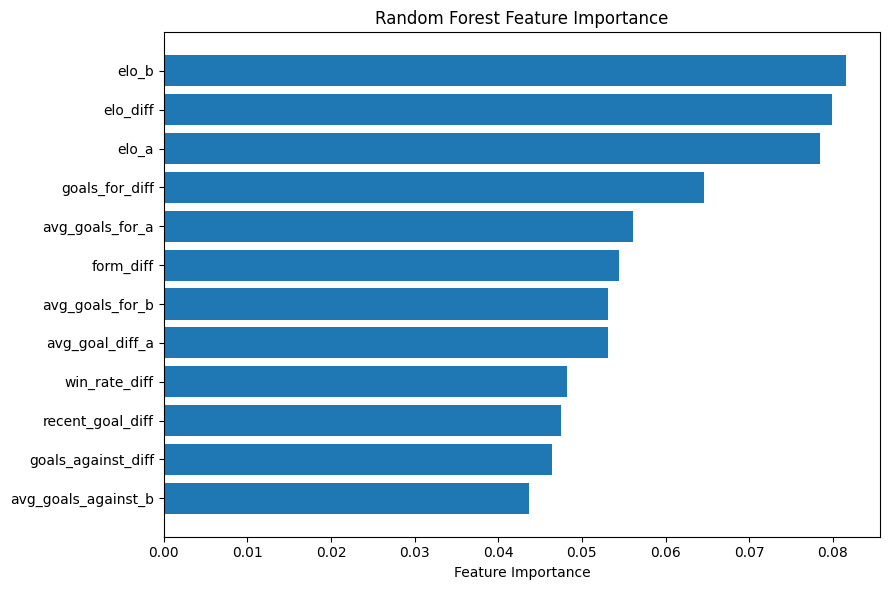

In [30]:
rf_importance = pd.DataFrame({
    "Feature":
        feature_cols,

    "Importance":
        random_forest_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

display(
    rf_importance.head(15)
)


top_features = rf_importance.head(
    12
).sort_values(
    "Importance"
)


plt.figure(
    figsize=(9, 6)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel(
    "Feature Importance"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.tight_layout()

plt.show()

,Feature,Importance
15,win_rate_a,0.058407
17,win_rate_diff,0.057159
2,elo_diff,0.053462
6,avg_goals_for_a,0.051957
19,recent_games_b,0.051649
12,avg_goal_diff_a,0.050551
8,goals_for_diff,0.050327
1,elo_b,0.050093
20,is_knockout,0.049099
7,avg_goals_for_b,0.046767


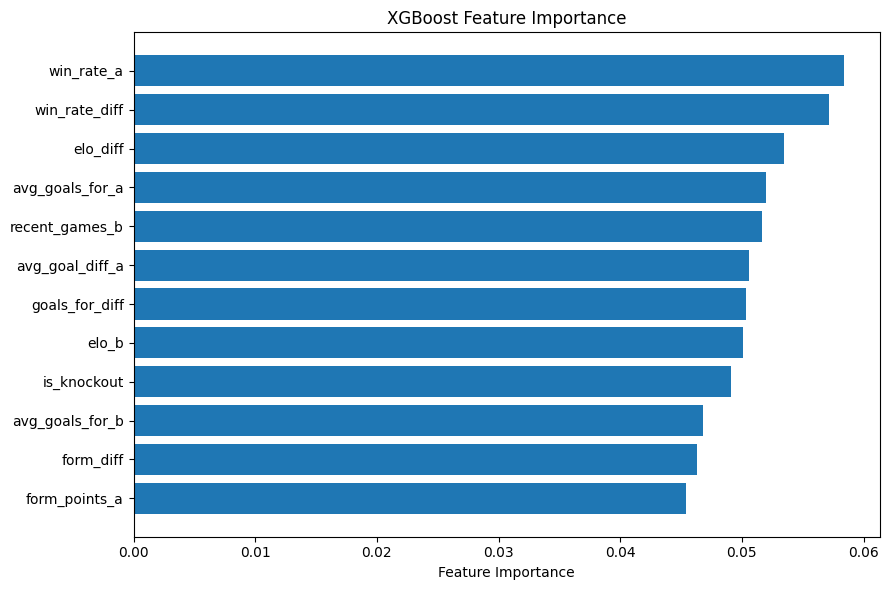

In [31]:
xgb_importance = pd.DataFrame({
    "Feature":
        feature_cols,

    "Importance":
        xgboost_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    "Importance",
    ascending=False
)

display(
    xgb_importance.head(15)
)


top_features = xgb_importance.head(
    12
).sort_values(
    "Importance"
)


plt.figure(
    figsize=(9, 6)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel(
    "Feature Importance"
)

plt.title(
    "XGBoost Feature Importance"
)

plt.tight_layout()

plt.show()

In [32]:
result_lookup = {
    0: "Team B Win",
    1: "Draw",
    2: "Team A Win"
}


columns_to_show = [
    "date",
    "tournament",
    "year",
    "team_a",
    "team_b",
    "target"
]

test_matches = matches.iloc[
    test_idx
][columns_to_show].copy()


test_matches["Actual Result"] = (
    test_matches["target"]
    .map(result_lookup)
)


for model_name, pred in predictions.items():

    test_matches[
        model_name
    ] = [
        result_lookup[int(x)]
        for x in pred
    ]


display(
    test_matches
    .drop(columns="target")
    .head(30)
)

,date,tournament,year,team_a,team_b,Actual Result,Logistic Regression,Random Forest,Gradient Boosting,XGBoost,Poisson
87,2014-06-20,World Cup,2014,Italy,Costa Rica,Team B Win,Team A Win,Team B Win,Team A Win,Team A Win,Team B Win
7,2010-06-13,World Cup,2010,Germany,Australia,Team A Win,Team A Win,Team B Win,Team A Win,Team A Win,Team A Win
233,2021-06-28,European Championship,2020,France,Switzerland,Draw,Team A Win,Team A Win,Team A Win,Team A Win,Team B Win
347,2024-07-01,European Championship,2024,France,Belgium,Team A Win,Draw,Team A Win,Draw,Team A Win,Team A Win
103,2014-06-24,World Cup,2014,Costa Rica,England,Draw,Team B Win,Team A Win,Team A Win,Team A Win,Draw
176,2018-06-30,World Cup,2018,France,Argentina,Team A Win,Team B Win,Draw,Draw,Draw,Team A Win
277,2022-11-29,World Cup,2022,Wales,England,Team B Win,Team B Win,Team B Win,Team B Win,Team B Win,Team B Win
115,2014-06-29,World Cup,2014,Costa Rica,Greece,Draw,Team B Win,Team A Win,Team A Win,Team A Win,Team B Win
170,2018-06-27,World Cup,2018,South Korea,Germany,Team A Win,Team B Win,Team B Win,Team A Win,Team B Win,Team A Win
323,2024-06-20,European Championship,2024,Slovenia,Serbia,Draw,Team B Win,Draw,Draw,Draw,Team B Win


In [33]:
results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

cv_results_df.to_csv(
    "cross_validation_results.csv",
    index=False
)

test_matches.to_csv(
    "test_match_predictions.csv",
    index=False
)

rf_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

xgb_importance.to_csv(
    "xgboost_feature_importance.csv",
    index=False
)


print("Files saved successfully:")
print("model_comparison_results.csv")
print("cross_validation_results.csv")
print("test_match_predictions.csv")
print("random_forest_feature_importance.csv")
print("xgboost_feature_importance.csv")

Files saved successfully:
model_comparison_results.csv
cross_validation_results.csv
test_match_predictions.csv
random_forest_feature_importance.csv
xgboost_feature_importance.csv
